## Project Overview

In this notebook, I build and evaluate text classification pipelines for Virtual Assistant Intent Recognition using the CLINC150 dataset.

Herein I:
1.  use the `clinc_oos` subset of the CLINC150 dataset containing specific virtual assistant intents.
2. Preprocess the text data using spaCy (tokenization, lemmatization, stop word removal).
3. Vectorize the text using a scikit-learn transformer
4. Train two different classifiers from scikit-learn:
    - Naive Bayes: `MultinomialNB`
    - Support Vector Machines: `LinearSVC`
4. Evaluate both models using accuracy, precision, recall, F1 score.
5. Discuss and analyze the results, focusing on the trade-offs between precision and recall in the context of different virtual assistant actions.

Intent subsets are chosen to maximize disambiguation difficulty — here I chose eight semantically similar travel-domain intents plus one out-of-domain banking intent in order to examine precision/recall tradeoffs in contexts where misclassification has real consequences for a user.

In [2]:
import warnings

import datasets
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import transformers

from sklearn.feature_extraction import text
from sklearn import model_selection
from sklearn import feature_extraction
from sklearn import metrics
from sklearn import naive_bayes
from sklearn import pipeline
from sklearn import svm
from transformers import pipeline

In [3]:
# Random seed
seed = 42

In [4]:
nlp = spacy.load("en_core_web_sm")

The CLINC150 dataset is a benchmark designed for Virtual Assistant Intent Recognition to develop and evaluate conversational AI systems. It comprises 22,500 user queries spanning all 150 intents. Each query is categorized into one of these intents, reflecting a wide array of user requests, from simple information retrieval to complex transactional commands.

The dataset is loaded via the HuggingFace `datasets` module.

In [5]:
with warnings.catch_warnings(category=UserWarning):
    dataset = datasets.load_dataset("clinc_oos", "plus")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

---

## Dataset Preparation

The dataset is retrieved from Hugging Face in a structure specific to that platform.

There are 3 subsets: "train", "validation", and "test".

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})

The data structure provided by Hugging Face is converted to a Pandas DataFrame

In [7]:
dataset["train"].to_pandas().head()

,text,intent
0,what expression would i use to say i love you ...,61
1,can you tell me how to say 'i do not speak muc...,61
2,"what is the equivalent of, 'life is good' in f...",61
3,"tell me how to say, 'it is a beautiful morning...",61
4,"if i were mongolian, how would i say that i am...",61


Given that by default, the labels are integers, rather than human-readable strings, it's necessary to retrieve the target labels from the dataset with the keys and attributes shown below.

The resulting list contains 150 unique intent labels.

In [8]:
intent_labels = dataset["train"].features["intent"].names

The following function creates a new column in a DataFrame that maps intent labels to their corresponding integer index. Afterward, it drops the integer column.

In [9]:
def replace_intent_labels(df: pd.DataFrame) -> pd.DataFrame:
    df["intent_name"] = df["intent"].map(lambda x: intent_labels[x])
    return df.drop(columns="intent")

`replace_intent_labels()` function applied to all 3 of the data subsets.

In [10]:
df_train = replace_intent_labels(
    dataset["train"].to_pandas()
)
df_validation = replace_intent_labels(
    dataset["validation"].to_pandas()
)
df_test = replace_intent_labels(
    dataset["test"].to_pandas()
)

df_train.shape, df_validation.shape, df_test.shape

((15250, 2), (3100, 2), (5500, 2))

In order to explore the labels and some sentences from each, a set of 5 random samples is generated for each intent label. Labels and text from training set  are presented in a DataFrame

In [11]:
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(df_train.groupby("intent_name").sample(5).reset_index(drop=True))

,text,intent_name
0,does pho king in ceres take reservations,accept_reservations
1,do you know if whether or not zeus does reservations,accept_reservations
2,what locations of applebee's take reservations,accept_reservations
3,does cowgirl creamery in san francisco take reservations,accept_reservations
4,is it possible to make reservations in advance for macaroni grill,accept_reservations
5,why is my account blocked,account_blocked
6,i am very confused about the block that seems to have been placed on my account why is it there,account_blocked
7,what would cause my bank account to be frozen,account_blocked
8,why don't i have access to my bank account,account_blocked
9,can you explain to me why my bank account might be frozen,account_blocked


In [28]:
# check how many of each intent tag
df_train["intent_name"].value_counts()[:51]

,count
intent_name,
transfer,100
travel_alert,100
flight_status,100
confirm_reservation,100
distance,100
lost_luggage,100
travel_suggestion,100
travel_notification,100
exchange_rate,100


In [27]:
# examine just the "transfer" tagged items
df_train.loc[df_train["intent_name"] =="transfer",] # oos = out of scope, not useful

,text,intent_name,processed_text
100,i need $20000 transferred from my savings to my checking,transfer,need transfer saving checking
101,complete a transaction from savings to checking of $20000,transfer,complete transaction saving checking
102,transfer $20000 from my savings account to checking account,transfer,transfer saving account check account
103,take $20000 from savings and put it in checking,transfer,saving check
104,put $20000 into my checking account from my savings account,transfer,checking account saving account
105,send 100 dollars between bank of the west and bank of america acccounts,transfer,send dollar bank west bank america acccount
106,send 50 dollars between bank of america and chase accounts,transfer,send dollar bank america chase account
107,send 2000 dollars between chase and rabobank accounts,transfer,send dollar chase rabobank account
108,send 1200 dollars between usaa and navy federal accounts,transfer,send dollar usaa navy federal account
109,send 400 dollars between city bank and usaa accounts,transfer,send dollar city bank usaa account


### Intents for Classification

Nine intents were chosen, most having to do with the domain/theme of `TRAVEL`.
The grouping of the 8 similar (TRAVEL) intents are chosen to test the model's ability to distinguish them from eachother. The mismatching `transfer` intent (which is a *bank* transfer) is included to test how well the models are able to disambiguate this standalone intent, which is not related to the others (aside from a marginal relation to 'exchange rate', specifically in the sense of they are in the `BANKING` domain).



In [13]:
selected_intents = [
    "travel_alert",
    "flight_status",
    "confirm_reservation",
    "distance",
    "lost_luggage",
    "travel_suggestion",
    "travel_notification",
    "exchange_rate",
    "transfer"
]

Dataset is filtered so that:
* there are 3 subsets (*train, test, validation*)
* they only include the 9 intents defined above

In [14]:
from numpy import isin

df_train = df_train[df_train['intent_name'].isin(selected_intents)].copy()
df_test = df_test[df_test['intent_name'].isin(selected_intents)].copy()
df_validation = df_validation[df_validation['intent_name'].isin(selected_intents)].copy()

Here the train, validation and test DataFrames are split into features (X's) and target labels (y's). These variables are reused throughout this Notebook.

In [15]:
X_train = df_train["text"]
y_train = df_train["intent_name"]

X_validation = df_validation["text"]
y_validation = df_validation["intent_name"]

X_test = df_test["text"]
y_test = df_test["intent_name"]

X_train.shape, y_train.shape, X_validation.shape, y_validation.shape, X_test.shape, y_test.shape

((900,), (900,), (180,), (180,), (270,), (270,))

---

## Text Preprocessing and Vectorization

Tokenizer function defined (using spaCy) that will be passed to the scikit-learn transformer. Function:
- Removes stop words
- Removes punctuation
- Returns the lemmatized form of the remaining tokens joined as a single string

In [16]:
def spacy_tokenizer(text: str) -> str:
    doc = nlp(text)
    return ' '.join(token.lemma_ for token in doc if token.is_alpha and not token.is_stop)

3 subsets are transformed into numerical matrices using scikit-learn `fit_transform` is only on the training data, while the other 2 subsets must simply use `transform`.

In [17]:

# apply tokenizers to each of the 3 datasets, redefine the variables
df_train["processed_text"] = df_train["text"].apply(spacy_tokenizer)
X_train_text = df_train["processed_text"]

df_test["processed_text"] = df_test["text"].apply(spacy_tokenizer)
X_test_text = df_test["processed_text"]

df_validation["processed_text"] = df_validation["text"].apply(spacy_tokenizer)
X_validation_text = df_validation["processed_text"]

# can this be created and used by all 3 sets?
tfidf = text.TfidfVectorizer(max_features=3000)

# Vectorize for train
# Fit on processed training data, then transform training data.
X_train_fit = tfidf.fit_transform(X_train_text)

# Only transform test data (using the vocabulary learned from training).
X_test_transform = tfidf.transform(X_test_text)

# test output
X_train_fit.shape, X_test_transform.shape

((900, 682), (270, 682))

---

## Training and Evaluation of Models

Because the vectorizer expects a sequence of strings rather than a list of tokens, `spacy_tokenizer` is applied to training and testing text lists to create new, preprocessed lists.

### Naive Bayes

Training data is fit to a `MultinomialNB` model.

Note: Since I'm not tuning hyperparameters for this model, I'm not using the validation set here.

In [18]:
nb_clf = naive_bayes.MultinomialNB()
# X_train_fit: defined above in tfidf.fit_transform, y_train are the labels (same no matter what iteration)
nb_clf.fit(X_train_fit, y_train)

MultinomialNB()

 Predictions are stored in variable `y_pred_nb`.

The classification report below shows: precision, recall, f1-score and support for the evaluation of each label.

In [19]:
y_pred_nb = nb_clf.predict(X_test_transform)
print(metrics.classification_report(y_test, y_pred_nb))

                     precision    recall  f1-score   support

confirm_reservation       0.94      1.00      0.97        30
           distance       1.00      0.83      0.91        30
      exchange_rate       1.00      1.00      1.00        30
      flight_status       0.91      1.00      0.95        30
       lost_luggage       0.91      1.00      0.95        30
           transfer       1.00      0.97      0.98        30
       travel_alert       1.00      0.97      0.98        30
travel_notification       0.88      1.00      0.94        30
  travel_suggestion       1.00      0.83      0.91        30

           accuracy                           0.96       270
          macro avg       0.96      0.96      0.95       270
       weighted avg       0.96      0.96      0.95       270



In the confusion matrix below, the y-axis represents actual labels and the x-axis represents predicted labels. This table shows how often the model confused one label with another.

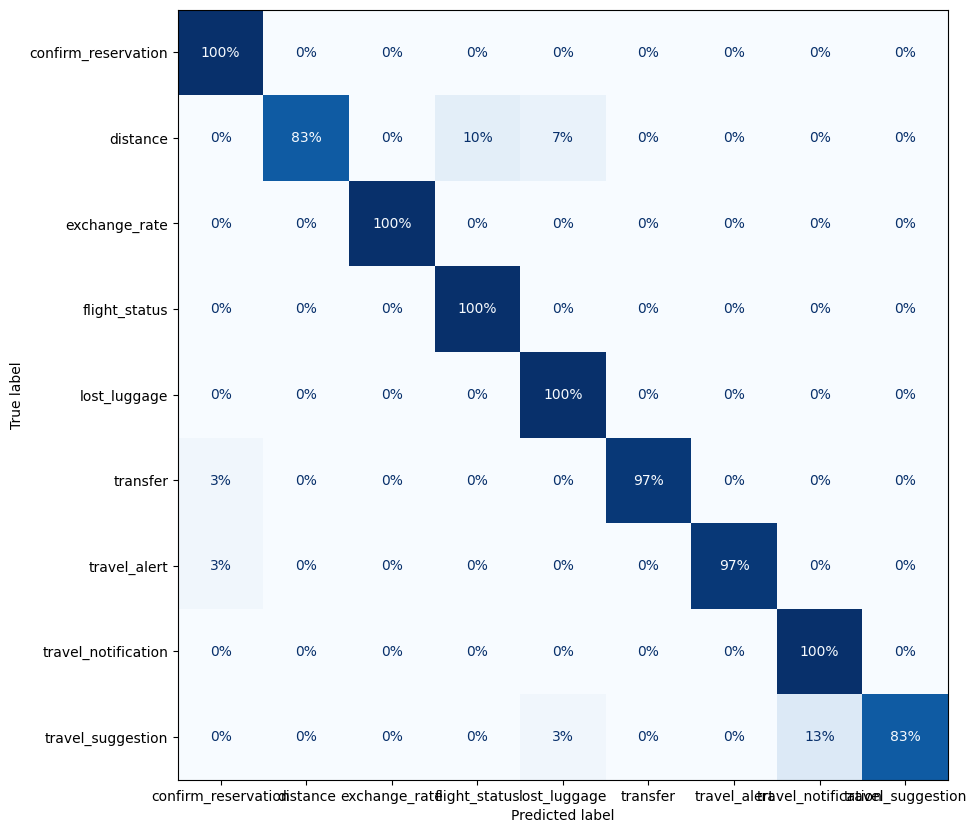

In [20]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    normalize="true",
    values_format=".0%",
    cmap="Blues",
    colorbar=False,
    ax=plt.subplots(figsize=(10, 10))[1]
)

### Linear Support Vector Machines

For this SVM, hyperparameters are tuned with `C`. The first value tried is 1.0 however 7 other values are tested below as well.

In [21]:
C = 1.0       # Initial value of C

The training data is fit to a `LinearSVC` model, using `C` above as the model's regularization hyperparameter.

In [22]:
svm_clf = svm.LinearSVC(C=C)
svm_clf.fit(X_train_fit, y_train)

LinearSVC()

**Validation set** is used to make predictions and create a classification report. Function `change_c()` the set is run for 8 different values for `C` in order to determine the best choice.


In [23]:
def change_c(C):
  svm_clf = svm.LinearSVC(C=C)

  scores = model_selection.cross_val_score(
      svm_clf,
      X_train_fit,
      y_train,
      cv=5      # Number of folds for cross-validation.
  )

  return scores.mean() # Average score across all validations.

c_vals = [0.01, 0.1, 1.0, 2.0, 2.5, 3.0, 10, 100]
c_scores = [change_c(val) for val in c_vals]
svm_results_c = pd.DataFrame({
    "C": c_vals,
    "c_scores": c_scores

})

svm_results_c

,C,c_scores
0,0.01,0.938889
1,0.10,0.956667
2,1.00,0.965556
3,2.00,0.961111
4,2.50,0.960000
5,3.00,0.960000
6,10.00,0.960000
7,100.00,0.960000


The model is used to make predictions, they are stored in the variable named `y_pred_svm`, and a classification report is generated below.

In [24]:
y_pred_svm = svm_clf.predict(X_test_transform)
print(metrics.classification_report(y_test, y_pred_svm))

                     precision    recall  f1-score   support

confirm_reservation       1.00      1.00      1.00        30
           distance       0.97      0.93      0.95        30
      exchange_rate       1.00      1.00      1.00        30
      flight_status       1.00      1.00      1.00        30
       lost_luggage       1.00      1.00      1.00        30
           transfer       0.97      1.00      0.98        30
       travel_alert       1.00      0.93      0.97        30
travel_notification       0.97      0.97      0.97        30
  travel_suggestion       0.91      0.97      0.94        30

           accuracy                           0.98       270
          macro avg       0.98      0.98      0.98       270
       weighted avg       0.98      0.98      0.98       270



Again, a confusion matrix is generated below to show what types of mistakes the model made.

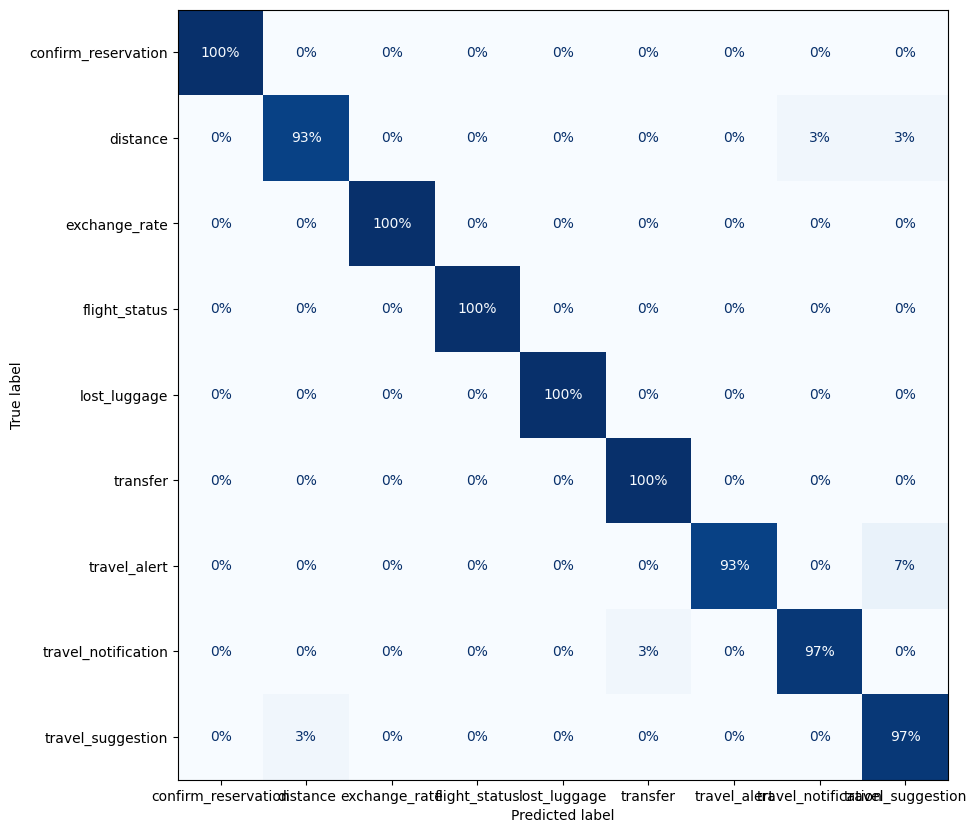

In [25]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    normalize="true",
    values_format=".0%",
    cmap="Blues",
    colorbar=False,
    ax=plt.subplots(figsize=(10, 10))[1]
)

## Error Analysis

The DataFrame below shows all cases where at least one model predicted incorrectly, displaying the original text, preprocessed text, true label, and both model predictions side by side. This allows direct inspection of the linguistic features that led to misclassification.

In [26]:
# Visualization of original and predicted labels, with text & processed_text
results_df = pd.DataFrame({
    "text": df_test["text"],
    "processed_text": df_test["processed_text"],
    "label": df_test["intent_name"],
    "pred_nb": y_pred_nb,
    "pred_svm": y_pred_svm
})

pd.set_option('display.max_rows', None)
pd.set_option("display.max_colwidth", None)
# check where predictions wrong (both models)
results_df.loc[(results_df["label"] != results_df["pred_svm"]) | (results_df["label"] != results_df["pred_nb"])]

,text,processed_text,label,pred_nb,pred_svm
53,repeat what the weather will be like,repeat weather like,transfer,confirm_reservation,transfer
231,does the state department say anything about traveling to haiti,state department travel haiti,travel_alert,travel_alert,travel_suggestion
235,safety concerns for malaysia,safety concern malaysia,travel_alert,confirm_reservation,travel_suggestion
905,how much time is left until we get there,time leave,distance,flight_status,distance
910,is it going to be much longer until i reach the bank,go long reach bank,distance,distance,travel_notification
913,when will i arrive at hy-vee,arrive hy vee,distance,lost_luggage,distance
923,give me an eta on when i will arrive at my destination,eta arrive destination,distance,flight_status,distance
925,when will i get to orlando,orlando,distance,distance,travel_suggestion
927,do i have a ways to go or am i close to getting to penn station,way close get penn station,distance,lost_luggage,distance
929,can you tell me about what time i should be arriving at the airport,tell time arrive airport,distance,flight_status,distance


### Analysis: Impact of Stopword Removal on Intent Classification

I think for the most part removing stopwords helps, however there were some cases where removal clearly hurt the results (mostly in NB). I think that the Spacy stopword list is actually a bit too extensive, and there are some contexts where removal of some of the words therein contributes negatively, in particular in the context of multi-word expressions that involve common words but as a whole, carry semantically relevant domain or intent-specific information. Below are several examples:

Example 1
* Original text: '*when will i arrive at hy-vee*?   
* Processed text: arrive hy vee
* NB prediction: `distance`
* Actual label: `lost_luggage`

Note: 'when' is an important word in domains where time is a crucial element, removing it is harmful to classification

Note 2: this Q doesn't have anything that would logically lead a human to conclude it's about lost_luggage, it doesn't really make sense that the SVM model concluded this

Example 2
* Original text: '*how much time is left* until we get there?'
* Processed text: time leave
* NB prediction: `flight_status`
* Actual label: `distance`

Note: based on the processed text version with the phrase 'how much time is left' removed, what's left is a prototypical Q asking about flight or other kind of travel status check. Again, not sure how/why the SVM would get this label correct based on the processed_version

Example 3
* Original text: 'i am traveling to paris soon and would like some suggestions of what to do and see'
* Processed text: 'travel paris soon like suggestion'
* NB prediction: `travel_notification`
* Actual label: `travel_suggestion`

Note: if only considering '*travel paris soon*', this does look like a travel notification, thus from this perspective, removing 'would like some suggestions of what to do and see' (most of whose lemmas are stopwords) would seem to be a cause of this mislabeling. However, the term '*suggestion*' in the processed text should've been enough to classify correctly.

The NB model's failure here may be attributable to its bag-of-words assumption. By treating each token independently without regard to word order or context, the model can't capture the semantic intent of multi-word expressions like "*would like some suggestions.*"

Example 4
* Original text: 'when will i get to orlando'
* Processed text: orlando
* SVM prediction: '`travel_suggestion`'
* Actual label: `distance`

Note: in this case the removal of stopwords is totally harmful to classification, '*when will I get to*' is equally importantly semantically as the destination 'Orlando'

Example 5
* Original text: 'let me know some things to do in phoenix'
* Processed text: let know thing phoenix
* NB label: `travel_notification`
* Actual label: `travel_suggestion`

Note: removing '*things to do*' is very counterproductive to labelling '*travel suggestions*' as that is a prototypical phrase associated with the domain of travel. Though, given that MultinomialNB does not leverage word order and multi-word expressions, this phrase likely wouldn't have picked up the relevance of this in context anyway.

Note: However, '*let know' which ended up in the 'processed text*' likely should've been enough to determine the correct label.

### Precision vs. Recall Tradeoffs by Intent

Where NB had significantly higher precision than recall:

| Intent | Precision | Recall |
|---|---|---|
| distance | 1.00 | 0.83 |
| travel_suggestion | 1.00 | 0.83 |

Where SVM had significantly higher precision than recall:

| Intent | Precision | Recall |
|---|---|---|
| travel_alert | 1.00 | 0.93 |

In practical terms for a virtual assistant in which a given model had a higher precision and significantly lower recall would mean that: a user's question about distance is not answered, and a travel suggestion is not provided (NB respectively), and a travel alert is not given (SVM)


Where NB had significantly higher recall than precision:

| Intent | Precision | Recall |
|---|---|---|
| travel_notification | 0.88 | 1.00 |


Where SVM had significantly higher recall than precision:

| Intent | Precision | Recall |
|---|---|---|
| travel_suggestion | 0.91 | 0.97 |


In the cases where a model had significantly higher recall than precision, this means that: when a user was asking for something else, the agent sent a travel notification to them (in the NB instance), and when the user was asking for something else, the agent gave a travel suggestion.

For intents distance & travel_suggestion, where the stakes are lower if the agent doesn't perform the action, it would be ok to prioritize Precision more than Recall.

For the intents travel_alert and travel_notification, I would prioritize Recall because if a user is relying on an important notification or alert regarding their travel, missing it would be of significant inconvenience.

### High-Stakes Misclassification: The Cost of a False Positive

In this example, the mistaken classification (SVM) leads to a bank transfer, which is a costly, significant mistake which costs the user money, and possibly business implications for the provider of the assistant. This is a result of a *false positive*, and thus a Precision error.

* Original text: *send a notification to my bank of my travel dates from february 19th to 26th to peru*
* Processed text: send notification bank travel date february peru
* SVM Prediction: `transfer`
* Actual label: travel_notification

### Low-Stakes Misclassification: The Cost of a False Negative

If a user asks for a travel suggestion and instead model doesn't recognize the intent and the suggestion isn't provided, this is a failure of recall. In such cases the stakes are low, the user can just try again and no irreversible action has been done (in contrast to the previous case, where a travel notification was requested and the misclassification would've lead to bank transfer). An example of such a case is in an example discussed above:

* Original text: 'i am traveling to paris soon and would like some suggestions of what to do and see'
* Processed text: 'travel paris soon like suggestion'
* NB prediction: `travel_notification`
* Actual label: `travel_suggestion`

### Overall Model Performance and Linguistic Analysis of Confusion

In all, the SVM model performed marginally better, the macro & weighted accuracy averages for Precision, Recall and F1 scores was 0.98, whereas the NB model the macro & weighted accuracy averages for each Precision, Recall were 0.96 and F1 was 0.95. The one blemish on the SVM model, as discussed, was that there were Recall errors on intents of relatively high importance, i.e. 'travel_alert' and 'travel_notification'.

In NB, 'distance' was confused for 'flight status' (10%) and 'lost luggage' (7%), and the most significant, was that 'travel suggestion' was confused for 'travel notification' 13% of the time.

Regarding possible linguistic phrasing causes that could've led to these confusions, for the case of 'distance' being confused for 'flight status',  there are clear explanations for this confusion.

The query "give me an eta on when i will arrive at my destination", after lemmatization became: "eta arrive destination", and
the query "can you tell me about what time i should be arriving at the airport" after lemmatization became: "tell time arrive airport". Each of these is asking about distance to destination but in terms of time (not actual distance), that phrasing is more akin to prototypical examples of checking the status of travel in progress, thus 'flight_status' was chosen.

With regards to 'distance' being confused for 'lost_luggage', this one is less obvious, neither of the two examples offer any linguistic based evidence as to why 'lost_luggage' would be the predicted label. These two are as follows (one was mentioned already above):

* "*when will i arrive at hy-vee*"	-> arrive hy vee
* "*do i have a ways to go or am i close to getting to penn station*"	->
way close get penn station